## **Data Analysis using Python Project - Blinkit Analysis**

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

####  Import Raw Data

In [2]:
df = pd.read_csv('blinkit_data.csv')

#### Sample Data

df.head()


In [3]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [4]:
df.info

<bound method DataFrame.info of      Item Fat Content Item Identifier              Item Type  \
0             Regular           FDX32  Fruits and Vegetables   
1             Low Fat           NCB42     Health and Hygiene   
2             Regular           FDR28           Frozen Foods   
3             Regular           FDL50                 Canned   
4             Low Fat           DRI25            Soft Drinks   
...               ...             ...                    ...   
8518          low fat           NCT53     Health and Hygiene   
8519          low fat           FDN09            Snack Foods   
8520          low fat           DRE13            Soft Drinks   
8521              reg           FDT50                  Dairy   
8522              reg           FDM58            Snack Foods   

      Outlet Establishment Year Outlet Identifier Outlet Location Type  \
0                          2012            OUT049               Tier 1   
1                          2022            OUT018  

#### Size of data

In [5]:
df.shape

(8523, 12)

In [6]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [7]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [8]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


#### Data Cleaning

In [9]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'low fat' : 'Low Fat', 'LF' : 'Low Fat', 'reg' : 'Regular'})

In [10]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


## **Business requirements**

## KPI's : Key Performance Indicator
#### 1. Total Sales
#### 2. Avg Sales
#### 3. Number of items
####  4. Avg Rating

In [20]:
#Total Sales
total_sales = df['Sales'].sum()

#avgerage sales
avg_sales = df['Sales'].mean() ## mean is used to calculate the mean 

#number of items sold
no_of_item_sold = df['Sales'].count()

#average rating
avg_rating = df['Rating'].mean()

#display the KPI's

print(f'Total Sales: ${total_sales}')

print(f'Average Sales : ${avg_sales}')

print(f'No. of items sold: {no_of_item_sold} items')

print(f'Average rating: {avg_rating} rating')

Total Sales: $1201681.4808
Average Sales : $140.9927819781767
No. of items sold: 8523 items
Average rating: 3.965857092573038 rating


##  Chart Requirements
#### 1. Total Sales by Fat content
#### 2. Total Sales by item type
#### 3. Fat content by outlet for total sales
#### 4. Sales by outlet size

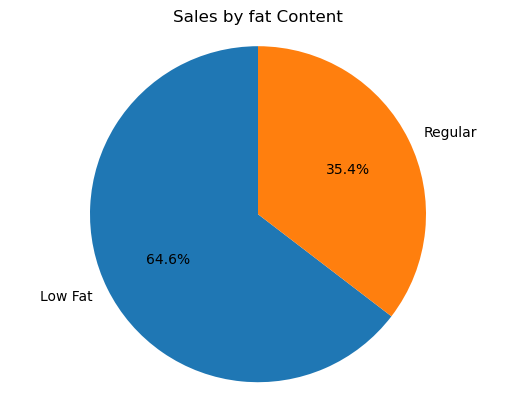

In [30]:
# 1. Total sales by fat content

sales_by_fat = df.groupby ('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat, labels = sales_by_fat.index,
                       autopct = '%.1f%%', 
                        startangle = 90)

plt.title('Sales by fat Content')
plt.axis('equal')
plt.show()



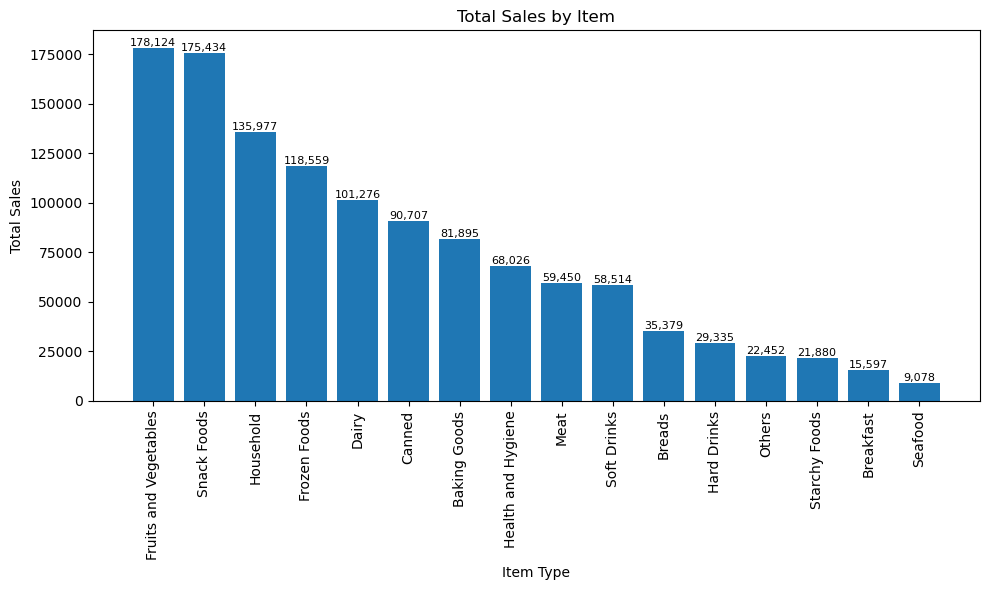

In [35]:
#Total Sales by item

sales_by_type = df.groupby ('Item Type')['Sales'].sum().sort_values(ascending = False)

plt.figure(figsize = (10,6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)
plt.xticks(rotation = 90)
plt.xlabel ('Item Type')
plt.ylabel('Total Sales')

plt.title('Total Sales by Item')


for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha = 'center', va = 'bottom', fontsize = 8)

plt.tight_layout()
plt.show()

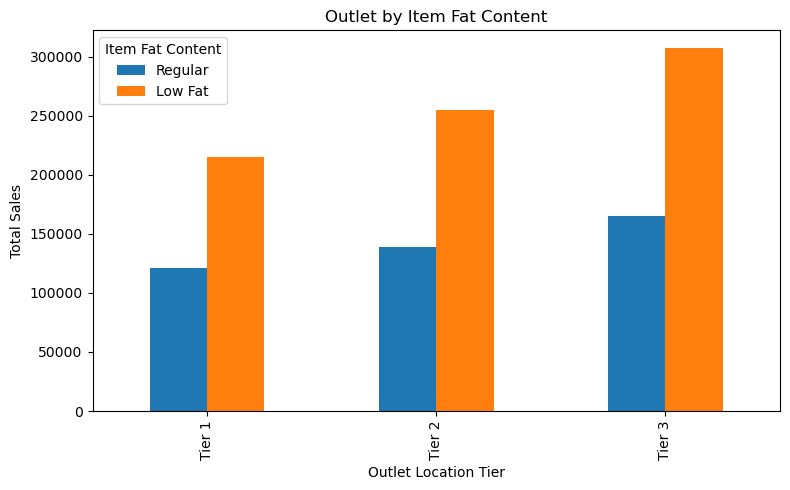

In [37]:
#Fat Content by Outlet Total Sales

grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind = 'bar', figsize = (8,5), title = 'Outlet by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title = 'Item Fat Content')
plt.tight_layout()
plt.show()

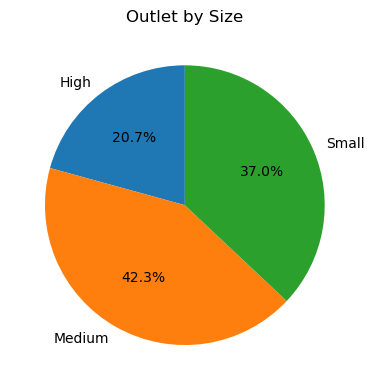

In [38]:
#Sales by Outlet Size

sales_by_size = df.groupby ('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_size, labels = sales_by_size.index,
            autopct = '%.1f%%',
            startangle = 90)

plt.title('Outlet by Size')
plt.tight_layout()
plt.show()